In [ ]:
import pandas as pd

df = pd.read_csv("movies.csv")

df = df.drop(columns=[
    'homepage', 'id', 'keywords', 'original_language',
    'original_title', 'overview', 'production_companies',
    'production_countries', 'spoken_languages', 'status',
    'tagline', 'title'
], errors='ignore')

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df = df.drop(columns=['release_date'])

df = df[(df['budget'] > 0) & (df['revenue'] > 0)]
df = df.dropna()

df['success'] = (df['revenue'] > df['budget']).astype(int)

print(df.columns)
print("Oldest movie:", df['release_year'].min())
print("Newest movie:", df['release_year'].max())

import ast

df['genre'] = df['genres'].apply(
    lambda x: ast.literal_eval(x)[0]['name']
    if pd.notnull(x) and len(ast.literal_eval(x)) > 0 else None
)

genre_counts = df['genre'].value_counts()

valid_genres = genre_counts[genre_counts >= 5].index

df = df[df['genre'].isin(valid_genres)]


Index(['budget', 'genres', 'popularity', 'revenue', 'runtime', 'vote_average',
       'vote_count', 'release_year', 'success'],
      dtype='str')
Oldest movie: 1916.0
Newest movie: 2016.0
genre
Drama              747
Comedy             634
Action             588
Adventure          288
Horror             197
Crime              141
Thriller           118
Animation           99
Fantasy             93
Science Fiction     79
Romance             70
Family              38
Documentary         30
Mystery             27
Western             22
Music               20
History             18
War                 18
Name: count, dtype: int64


success
1    2438
0     789
Name: count, dtype: int64
0.7555004648280136


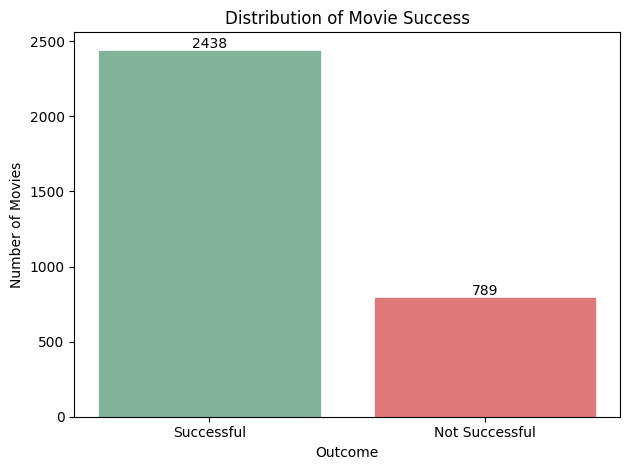

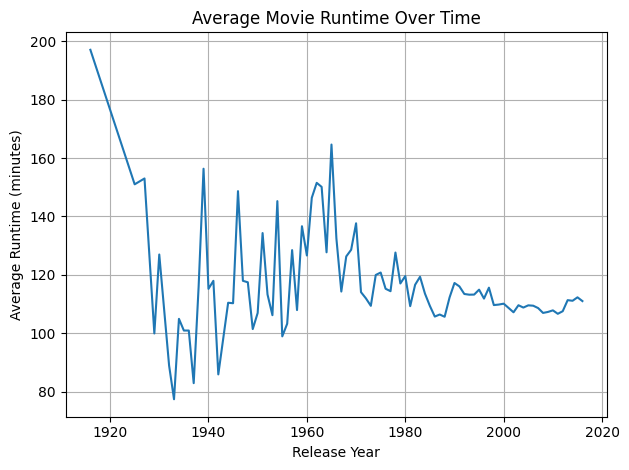

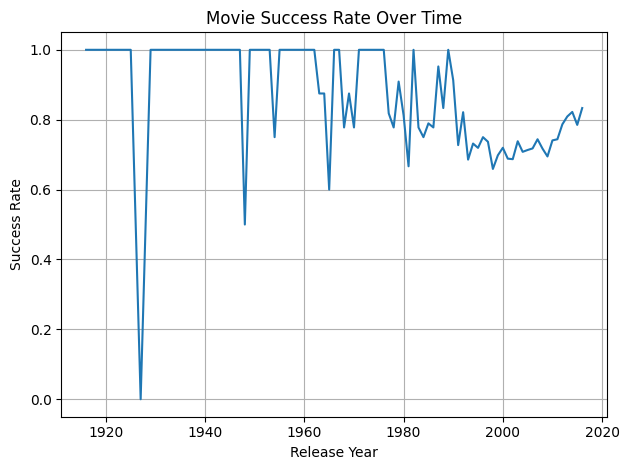

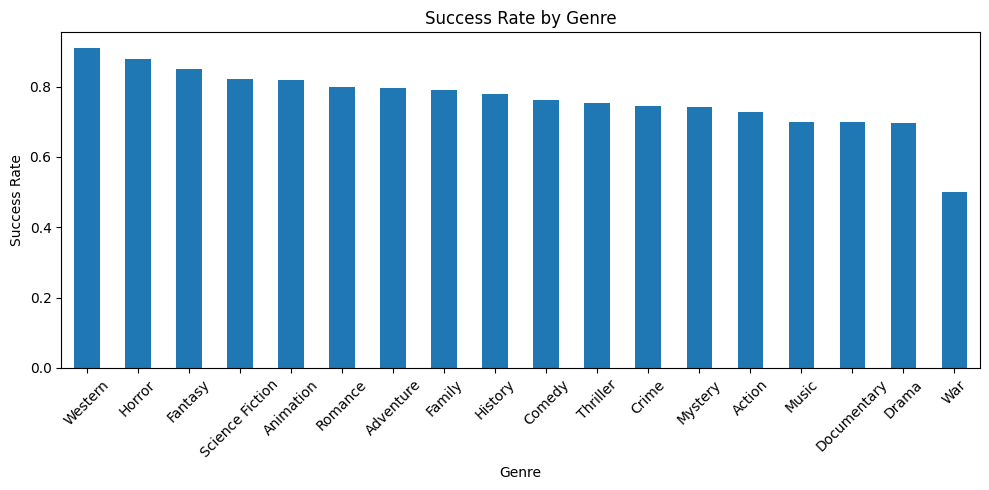

: 

In [ ]:
import matplotlib.pyplot as plt

print(df['success'].value_counts())
print(df['success'].mean())

# Map 0/1 to labels
labels = df['success'].map({0: 'Not Successful', 1: 'Successful'})
counts = labels.value_counts()

# Plot with colors
plt.figure()
bars = plt.bar(counts.index, counts.values)

# Set colors manually
bars[0].set_color('#81b29a')
bars[1].set_color('#e07a7a')

plt.title("Distribution of Movie Success")
plt.xlabel("Outcome")
plt.ylabel("Number of Movies")

for i, v in enumerate(counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

avg_runtime = df.groupby('release_year')['runtime'].mean()

plt.figure()
avg_runtime.plot()
plt.title("Average Movie Runtime Over Time")
plt.xlabel("Release Year")
plt.ylabel("Average Runtime (minutes)")
plt.grid(True)
plt.tight_layout()
plt.show()

success_rate = df.groupby('release_year')['success'].mean()

plt.figure()
success_rate.plot()
plt.title("Movie Success Rate Over Time")
plt.xlabel("Release Year")
plt.ylabel("Success Rate")
plt.grid(True)
plt.tight_layout()
plt.show()

import ast

# Extract first genre
df['genre'] = df['genres'].apply(lambda x: ast.literal_eval(x)[0]['name'] if pd.notnull(x) and len(ast.literal_eval(x)) > 0 else None)

genre_success = df.groupby('genre')['success'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
genre_success.plot(kind='bar')
plt.title("Success Rate by Genre")
plt.xlabel("Genre")
plt.ylabel("Success Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()